# Quantum vs Pseudorandom Bit Generation

## 1. Problem Statement
Generate random binary outcomes using a quantum circuit with a Hadamard gate and compare the resulting distribution with binary values generated using Python's random number generator. Use 2000 samples/shots and compare the frequencies and probabilities of 0 and 1.

---

## 2. Theoretical Concepts

### Quantum Random Bit Generation
In quantum computing, a qubit initialized in the computational ground state $|0\rangle$ can be placed into an equal superposition of basis states using a **Hadamard gate** ($H$):

$$H|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) = |+\rangle$$

In this state, the probability amplitudes for states $|0\rangle$ and $|1\rangle$ are identical: $\alpha = \frac{1}{\sqrt{2}}$ and $\beta = \frac{1}{\sqrt{2}}$. When measured in the computational basis, the quantum state collapses probabilistically into either $0$ or $1$. According to the **Born rule**, each measurement outcome has an equal theoretical probability:

$$P(0) = |\alpha|^2 = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2} = 0.5 \quad (50\%)$$

$$P(1) = |\beta|^2 = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2} = 0.5 \quad (50\%)$$

This measurement process demonstrates the fundamental, intrinsic probabilistic nature of quantum physics.

### Classical Pseudorandom Bit Generation
Python's standard `random` module uses a **Pseudorandom Number Generator (PRNG)** based on the Mersenne Twister algorithm. Unlike true physical randomness, PRNGs are deterministic algorithms: starting from an initial seed value, the entire sequence of generated numbers is completely determined by a mathematical formula. While the resulting values appear random and satisfy standard statistical tests for uniformity, they are inherently deterministic and reproducible.

### Purpose of Comparison
This experiment compares the observed empirical distributions of the two generators over a finite sample size. The objective is to examine and contrast their statistical distributions rather than to prove that one generator is statistically superior or more random than the other.

---

## 3. Expected Result
With a sufficiently large number of samples ($N = 2000$), both the quantum simulator and Python's pseudorandom generator are expected to produce approximately equal proportions of zeros and ones:
- **Theoretical Target**: $P(0) = 0.50$ ($1000$ counts) and $P(1) = 0.50$ ($1000$ counts) for both methods.
- **Sampling Variation**: Because the experiment samples a finite number of trials, natural sampling variation will cause the observed counts to fluctuate slightly around 1000 rather than being exactly identical.

---

## 4. Tools and Libraries
- **Qiskit**: Open-source quantum SDK for constructing, manipulating, and measuring quantum circuits.
- **Qiskit Aer (`AerSimulator`)**: High-performance simulator backend for executing quantum circuits.
- **Matplotlib**: Python data visualization library used to plot and compare the measurement distributions.
- **Python `random` module**: Standard library module providing pseudorandom bit generation via `random.randint(0, 1)`.

### Step 1: Import Libraries
Import `QuantumCircuit` from Qiskit for circuit modeling, `AerSimulator` from Qiskit Aer for simulation, `matplotlib.pyplot` for visualization, and `random` for pseudorandom bit generation.

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import random

/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_4128/4282957399.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


### Step 2: Generate Quantum Random Bits
Construct a 1-qubit, 1-classical-bit quantum circuit. Apply a Hadamard gate ($H$) to qubit 0 to prepare the equal superposition state $|+\rangle$, perform a measurement into the classical bit, and execute the circuit on `AerSimulator` for $N = 2000$ shots.

In [2]:
shots = 2000

qc = QuantumCircuit(1,1)

qc.h(0)

qc.measure(0,0)

backend = AerSimulator()

quantum_counts = backend.run(qc,shots=shots).result().get_counts()

### Step 3: Generate Python Pseudorandom Bits & Compare Measurement Counts
Generate 2000 pseudorandom binary values using Python's `random.randint(0, 1)`, count the occurrences of `0` and `1`, and display the raw count dictionaries for both generators.

In [3]:
python_bits = [random.randint(0,1) for _ in range(shots)]

python_counts = {}

python_counts['0'] = python_bits.count(0)

python_counts['1'] = python_bits.count(1)

print(quantum_counts)

print()

print(python_counts)

{'1': 1011, '0': 989}

{'0': 1013, '1': 987}


### Step 4: Extract Counts for Visualization
Structure the measurement counts for computational states `'0'` and `'1'` for both quantum and pseudorandom generators into ordered lists for plotting.

In [4]:
labels=['0','1']

quantum=[quantum_counts.get(i,0) for i in labels]

python=[python_counts[i] for i in labels]

### Step 5: Visualize the Distributions
Plot a side-by-side comparative bar chart showing the frequency distribution of generated bits for both the Quantum and Python generators.

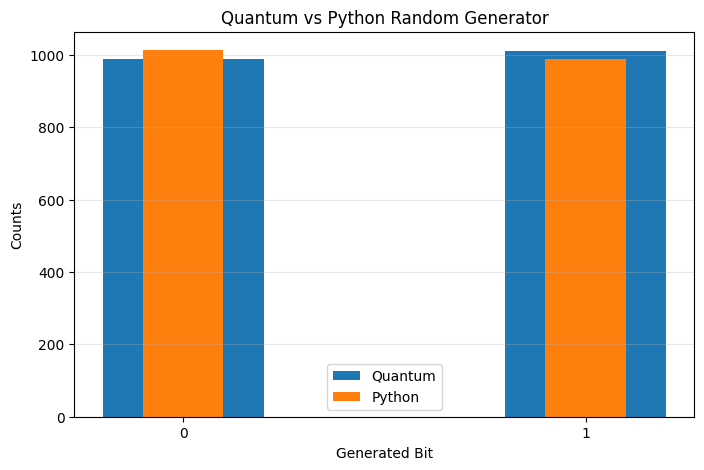

In [5]:
plt.figure(figsize=(8,5))

plt.bar(labels,quantum,width=0.4,label="Quantum")

plt.bar(labels,python,width=0.2,label="Python")

plt.title("Quantum vs Python Random Generator")

plt.xlabel("Generated Bit")

plt.ylabel("Counts")

plt.legend()

plt.grid(axis='y',alpha=0.3)

plt.show()

### Step 6: Compare Probabilities
Calculate the empirical probabilities ($P = \frac{\text{counts}}{\text{shots}}$) for both generators and present them in a structured comparison table.

In [6]:
print("Comparison\n")

print(f"{'Generator':<15}{'P(0)':<10}{'P(1)'}")

print("-"*35)

print(f"{'Quantum':<15}{quantum_counts.get('0',0)/shots:<10.4f}{quantum_counts.get('1',0)/shots:.4f}")

print(f"{'Python':<15}{python_counts['0']/shots:<10.4f}{python_counts['1']/shots:.4f}")

Comparison

Generator      P(0)      P(1)
-----------------------------------
Quantum        0.4945    0.5055
Python         0.5065    0.4935


### Step 7: Programmatic Summary Output
Print the summary output confirming that both generators produce nearly equal numbers of 0s and 1s.

In [7]:
print("\nConclusion\n")

print("Both generators produce nearly equal numbers of 0s and 1s.")

print("Quantum randomness is based on qubit measurement, whereas Python uses a deterministic pseudo-random algorithm.")


Conclusion

Both generators produce nearly equal numbers of 0s and 1s.
Quantum randomness is based on qubit measurement, whereas Python uses a deterministic pseudo-random algorithm.


## Conclusion

- **Balanced Outcomes**: In this experiment, both the quantum circuit simulation and Python's pseudorandom generator produced approximately balanced binary outcomes across 2000 trials:
  - **Quantum Generator**: $P(0) = 0.4945$ (989 counts), $P(1) = 0.5055$ (1011 counts)
  - **Python Pseudorandom Generator**: $P(0) = 0.5065$ (1013 counts), $P(1) = 0.4935$ (987 counts)
  Both empirical distributions closely match the theoretical expectation of $0.5$ ($50\%$) per outcome.
- **Underlying Mechanism**:
  - **Quantum Randomness**: Stemming from quantum superposition collapse, where measurement indeterminacy is a fundamental physical property.
  - **Classical Pseudorandomness**: Generated via a deterministic algorithmic sequence (Mersenne Twister) that mimics randomness from an initial internal seed.
- **Experimental Scope**: While both methods produce nearly balanced binary distributions at this sample size ($N = 2000$), this simple experiment demonstrates distributional similarity in basic sampling and does not prove that quantum randomness is statistically superior to Python's pseudorandom generator. Rigorous evaluation of randomness quality requires comprehensive statistical battery tests (such as NIST SP 800-22 or Dieharder) over large datasets.